In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../results/cnf_result_phi.csv")

In [15]:
df.head()

,timestamp_eval,dt_eval,eps_eval,num_noise_eval,integrator_eval,network,L,m2,lambda,dt,...,loss_avg,loss_err,part_avg,part_err,free_avg,free_err,ess_avg,ess_err,susc_avg,susc_err
0,20260610_151002,0.0025,0.00125,1,unbiasv2,phi4analytic,8,-4.0,6.008,0.5,...,-8.926436,0.008399,4.457770e+06,9.832204e+05,15.283950,0.216073,0.000173,0.000122,0.020857,0.002721
1,20260610_151002,0.0025,0.00125,1,unbiasv2,phi4analytic,8,-4.0,6.008,0.2,...,-11.439307,0.006956,1.136631e+07,3.969926e+06,16.197035,0.337489,0.000589,0.000731,0.044527,0.010789
2,20260610_151002,0.0025,0.00125,1,unbiasv2,phi4analytic,8,-4.0,6.008,0.1,...,-13.351277,0.005475,7.962574e+06,1.992484e+05,15.890303,0.025099,0.008523,0.002193,0.028644,0.000697
3,20260610_151002,0.0025,0.00125,1,unbiasv2,phi4analytic,8,-4.0,6.008,0.5,...,-15.350351,0.013113,1.051825e+12,4.267507e+11,27.593084,0.395619,0.000097,0.000090,0.018644,0.007053
4,20260610_151002,0.0025,0.00125,1,unbiasv2,phi4analytic,8,-4.0,6.008,0.2,...,-15.895974,0.008929,3.143685e+09,2.975936e+08,21.865202,0.093915,0.000660,0.000250,0.035248,0.003199


7
4
8
1
8
1


/tmp/ipykernel_262570/480364202.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend()


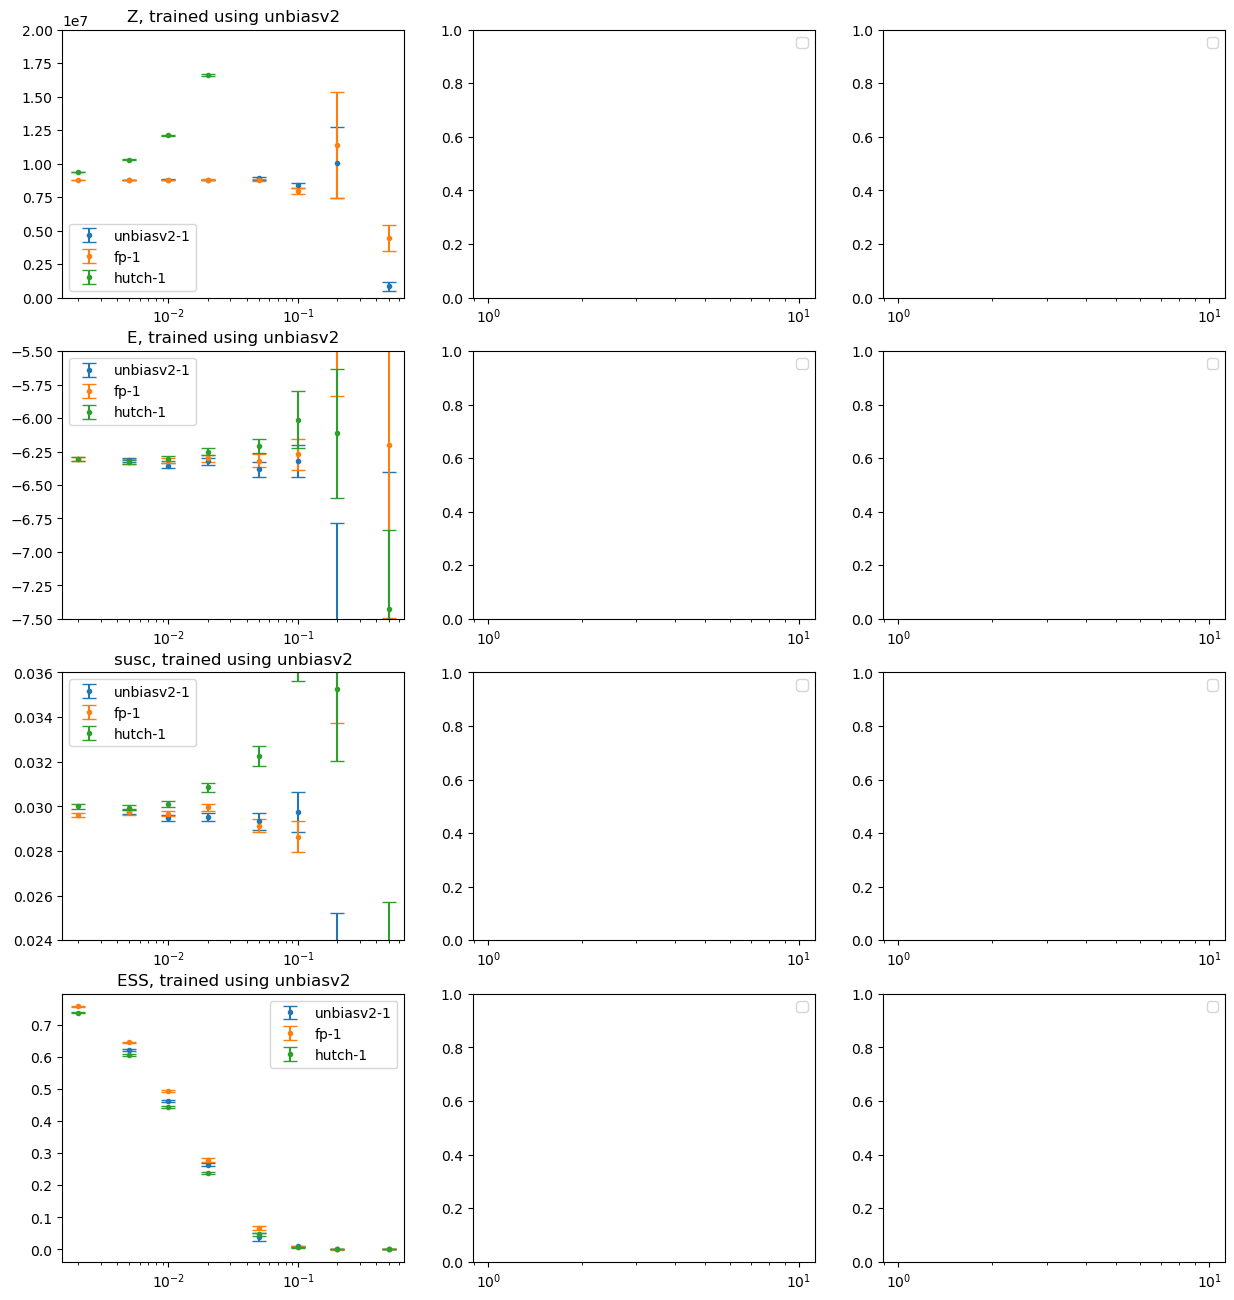

In [18]:
dg = df[df['L'] == 8]

integrators = ['unbiasv2', 'fp', 'hutch']
integratore = ['unbiasv2']
noises = [1]

fig, ax = plt.subplots(4, 3, figsize = (15, 16))
ax = ax.flatten()

for i, int in enumerate(integratore):
    for integrator in integrators:
        for noise in noises:
            dh = dg[(dg['integrator'] == integrator) & (dg['integrator_eval'] == int) & (dg['num_noise'] == noise)]
            dh = dh.sort_values(by='dt')
            print(len(dh))
            if len(dh) != 0:
                ax[i].errorbar(dh['dt']*(1 + 3 * (integrator=='unbiasv2')), dh['part_avg'], dh['part_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+3].errorbar(dh['dt']*(1 + 3 * (integrator=='unbiasv2')), dh['logp_avg'], dh['logp_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+6].errorbar(dh['dt']*(1 + 3 * (integrator=='unbiasv2')), dh['susc_avg'], dh['susc_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+9].errorbar(dh['dt']*(1 + 3 * (integrator=='unbiasv2')), dh['ess_avg'], dh['ess_err'], label = f'{integrator}-{noise}',
                                   linestyle = 'None', marker = '.', capsize = 5)
                print((1 + 3 * (integrator=='unbiasv2')))
    # di = dg[(dg['integrator'] == 'exact') & (dg['dt'] == 0.005)]
    # di = dg[(dg['integrator'] == 'exact')]
    # di = di.sort_values(by='dt')
    # ax[i].axhline(di['part_avg'].item())
    # ax[i].plot(di['dt'], di['part_avg'])
    ax[i].set_title(f'Z, trained using {int}')
    # ax[i+2].axhline(di['logp_avg'].item())
    # ax[i+3].plot(di['dt'], di['logp_avg'])
    ax[i+3].set_title(f'E, trained using {int}')
    # ax[i+4].axhline(di['susc_avg'].item())
    # ax[i+6].plot(di['dt'], di['susc_avg'])
    ax[i+6].set_title(f'susc, trained using {int}')
    ax[i+9].set_title(f'ESS, trained using {int}')
    # ax[i+9].plot(di['dt'], di['ess_avg'])
    for a in ax:
        a.set_xscale('log')
        a.legend()
    ax[i].set_ylim(0, 2e7)
    ax[i+3].set_ylim(-7.5, -5.5)
    ax[i+6].set_ylim(0.024, 0.036)
plt.show()

In [16]:
dg = df[df['L'] == 16]

In [15]:
print(len(dg))

265


/tmp/ipykernel_7729/2848446094.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend()


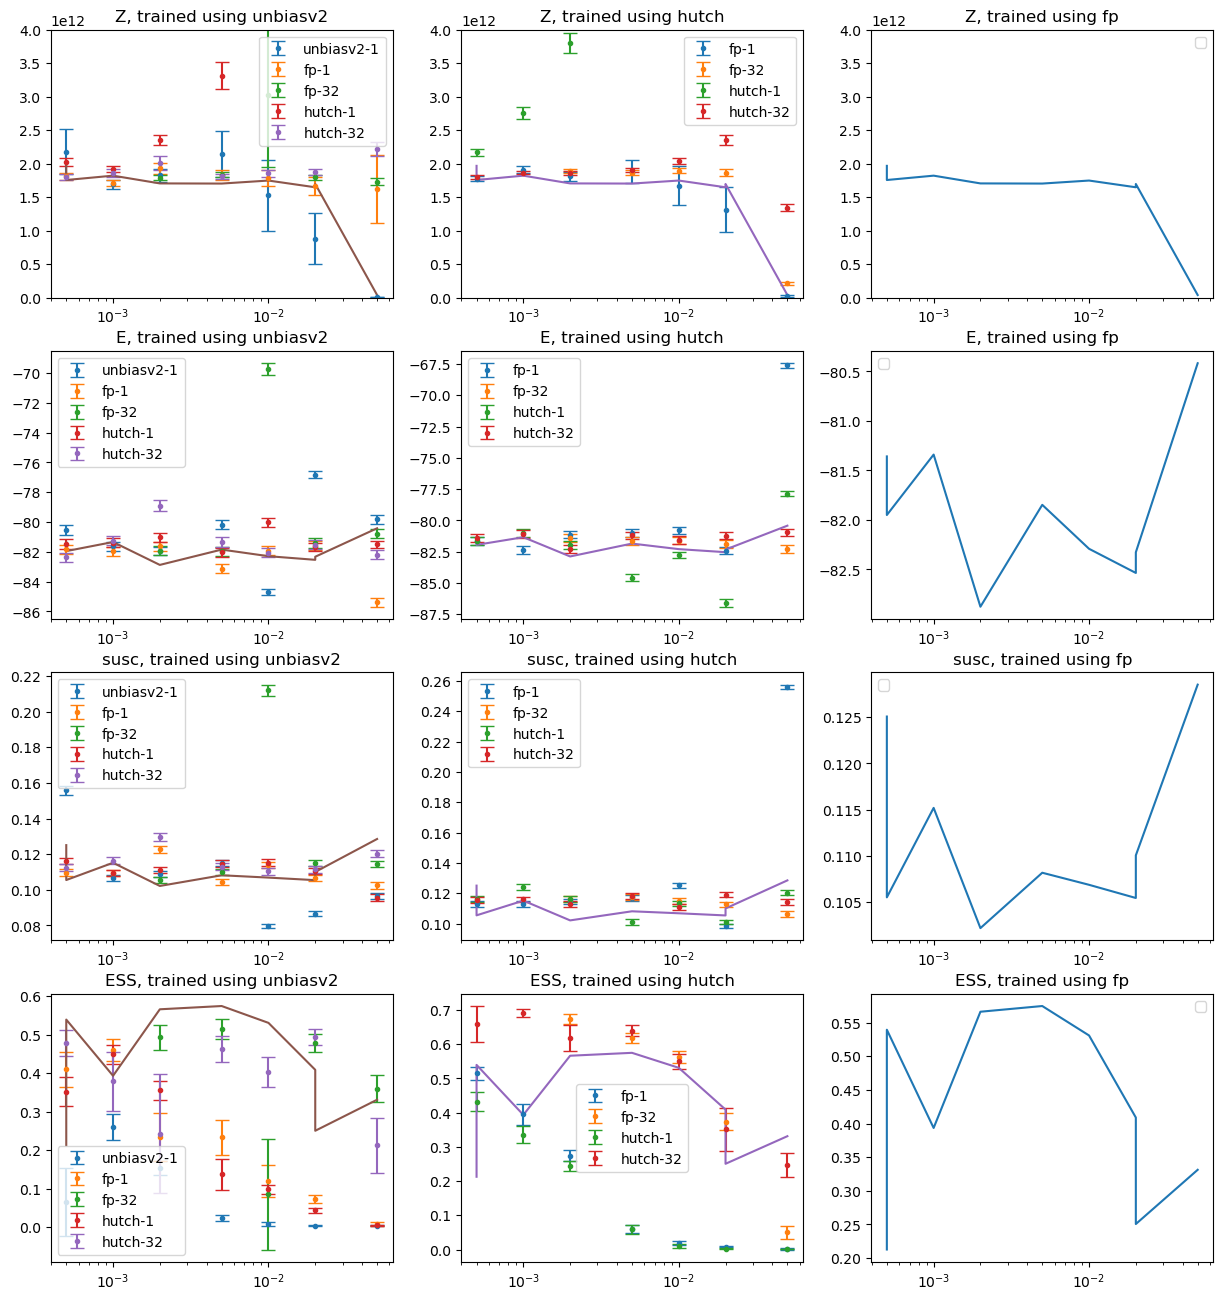

In [29]:
dg = df[df['L'] == 16]

integrators = ['unbiasv2', 'fp', 'hutch']
integratore = ['unbiasv2', 'hutch', 'fp']
noises = [1, 32]

fig, ax = plt.subplots(4, 3, figsize = (15, 16))
ax = ax.flatten()

for i, int in enumerate(integratore):
    for integrator in integrators:
        for noise in noises:
            dh = dg[(dg['integrator'] == integrator) & (dg['integrator_eval'] == int) & (dg['num_noise'] == noise)]
            dh = dh.sort_values(by='dt')
            if len(dh) != 0:
                ax[i].errorbar(dh['dt'], dh['part_avg'], dh['part_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+3].errorbar(dh['dt'], dh['logp_avg'], dh['logp_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+6].errorbar(dh['dt'], dh['susc_avg'], dh['susc_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+9].errorbar(dh['dt'], dh['ess_avg'], dh['ess_err'], label = f'{integrator}-{noise}',
                                   linestyle = 'None', marker = '.', capsize = 5)
    # di = dg[(dg['integrator'] == 'exact') & (dg['dt'] == 0.005)]
    di = dg[(dg['integrator'] == 'exact')]
    di = di.sort_values(by='dt')
    # ax[i].axhline(di['part_avg'].item())
    ax[i].plot(di['dt'][::5], di['part_avg'][::5])
    ax[i].set_title(f'Z, trained using {int}')
    # ax[i+2].axhline(di['logp_avg'].item())
    ax[i+3].plot(di['dt'][::5], di['logp_avg'][::5])
    ax[i+3].set_title(f'E, trained using {int}')
    # ax[i+4].axhline(di['susc_avg'].item())
    ax[i+6].plot(di['dt'][::5], di['susc_avg'][::5])
    ax[i+6].set_title(f'susc, trained using {int}')
    ax[i+9].set_title(f'ESS, trained using {int}')
    ax[i+9].plot(di['dt'][::5], di['ess_avg'][::5])
    for a in ax:
        a.set_xscale('log')
        a.legend()
    ax[i].set_ylim(0, 4e12)
    # ax[i+3].set_ylim(-7.5, -5.5)
    # ax[i+6].set_ylim(0.024, 0.036)
plt.show()

In [27]:
di = dg[(dg['integrator'] == 'exact')]
di = di.sort_values(by='dt')
di.head(40)

,timestamp_eval,dt_eval,eps_eval,num_noise_eval,integrator_eval,network,L,m2,lambda,dt,...,loss_avg,loss_err,part_avg,part_err,free_avg,free_err,ess_avg,ess_err,susc_avg,susc_err
445,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0005,...,-27.854893,0.022185,1.966254e+12,2.071906e+11,28.301764,0.102086,0.212619,0.230586,0.125073,0.002015
433,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0005,...,-27.849243,0.019068,1.715714e+12,3.661403e+10,28.169615,0.021638,0.520960,0.031854,0.105360,0.001717
434,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0005,...,-27.857450,0.025930,1.805724e+12,4.620858e+10,28.221819,0.024568,0.446372,0.055038,0.113938,0.001787
444,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0005,...,-27.837744,0.027759,1.767373e+12,3.452541e+10,28.199877,0.019880,0.556802,0.013963,0.106052,0.001788
437,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0005,...,-27.838724,0.026291,1.754856e+12,4.223451e+10,28.193739,0.023201,0.483435,0.033906,0.113326,0.001726
436,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0005,...,-27.884647,0.019383,1.754842e+12,3.678649e+10,28.193874,0.020320,0.539480,0.032439,0.105493,0.001726
414,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0010,...,-27.866070,0.020024,1.903229e+12,1.122670e+11,28.272879,0.057441,0.190002,0.127874,0.121646,0.001905
426,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0010,...,-27.854649,0.024807,1.763734e+12,3.687365e+10,28.197653,0.021221,0.537089,0.033150,0.107495,0.001772
413,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0010,...,-27.877819,0.019639,1.747358e+12,3.685188e+10,28.188511,0.020936,0.535219,0.026851,0.109343,0.001792
428,20260610_184727,0.005,0.0,1,exact,phi4analytic,16,-1.0,0.8,0.0010,...,-27.863708,0.025027,1.774643e+12,3.726320e+10,28.203728,0.021163,0.532110,0.027425,0.111064,0.001752


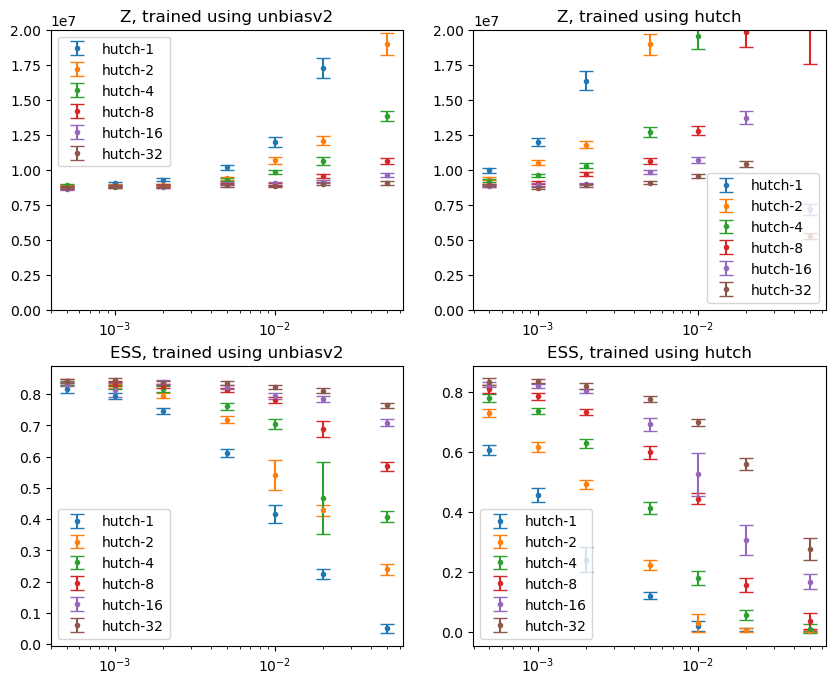

In [6]:
dg = df[df['L'] == 8]

integrators = ['hutch']
integratore = ['unbiasv2', 'hutch']
noises = [1, 2, 4, 8, 16, 32, 64]

fig, ax = plt.subplots(2, 2, figsize = (10, 8))
ax = ax.flatten()

for i, int in enumerate(integratore):
    for integrator in integrators:
        for noise in noises:
            dh = dg[(dg['integrator'] == integrator) & (dg['integrator_eval'] == int) & (dg['num_noise'] == noise)]
            dh = dh.sort_values(by='dt')
            if len(dh) != 0:
                ax[i].errorbar(dh['dt'], dh['part_avg'], dh['part_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+2].errorbar(dh['dt'], dh['ess_avg'], dh['ess_err'], label = f'{integrator}-{noise}',
                                   linestyle = 'None', marker = '.', capsize = 5)
    ax[i].set_title(f'Z, trained using {int}')
    ax[i+2].set_title(f'ESS, trained using {int}')
    for a in ax:
        a.set_xscale('log')
    ax[i].set_ylim(0, 2e7)
    ax[i].legend()
    ax[i+2].legend()
plt.show()

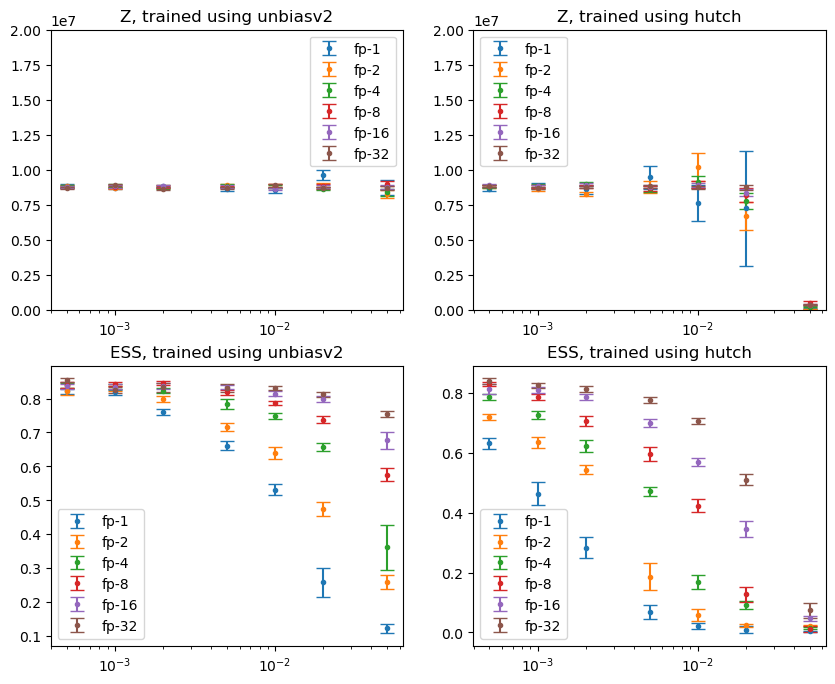

In [7]:
dg = df[df['L'] == 8]

integrators = ['fp']
integratore = ['unbiasv2', 'hutch']
noises = [1, 2, 4, 8, 16, 32, 64]

fig, ax = plt.subplots(2, 2, figsize = (10, 8))
ax = ax.flatten()

for i, int in enumerate(integratore):
    for integrator in integrators:
        for noise in noises:
            dh = dg[(dg['integrator'] == integrator) & (dg['integrator_eval'] == int) & (dg['num_noise'] == noise)]
            dh = dh.sort_values(by='dt')
            if len(dh) != 0:
                ax[i].errorbar(dh['dt'], dh['part_avg'], dh['part_err'], label = f'{integrator}-{noise}',
                                 linestyle = 'None', marker = '.', capsize = 5)
                ax[i+2].errorbar(dh['dt'], dh['ess_avg'], dh['ess_err'], label = f'{integrator}-{noise}',
                                   linestyle = 'None', marker = '.', capsize = 5)
    ax[i].set_title(f'Z, trained using {int}')
    ax[i+2].set_title(f'ESS, trained using {int}')
    for a in ax:
        a.set_xscale('log')
    ax[i].set_ylim(0, 2e7)
    ax[i].legend()
    ax[i+2].legend()
plt.show()